### Experiment: Trial run - Flashing blue LED light for 3 hours

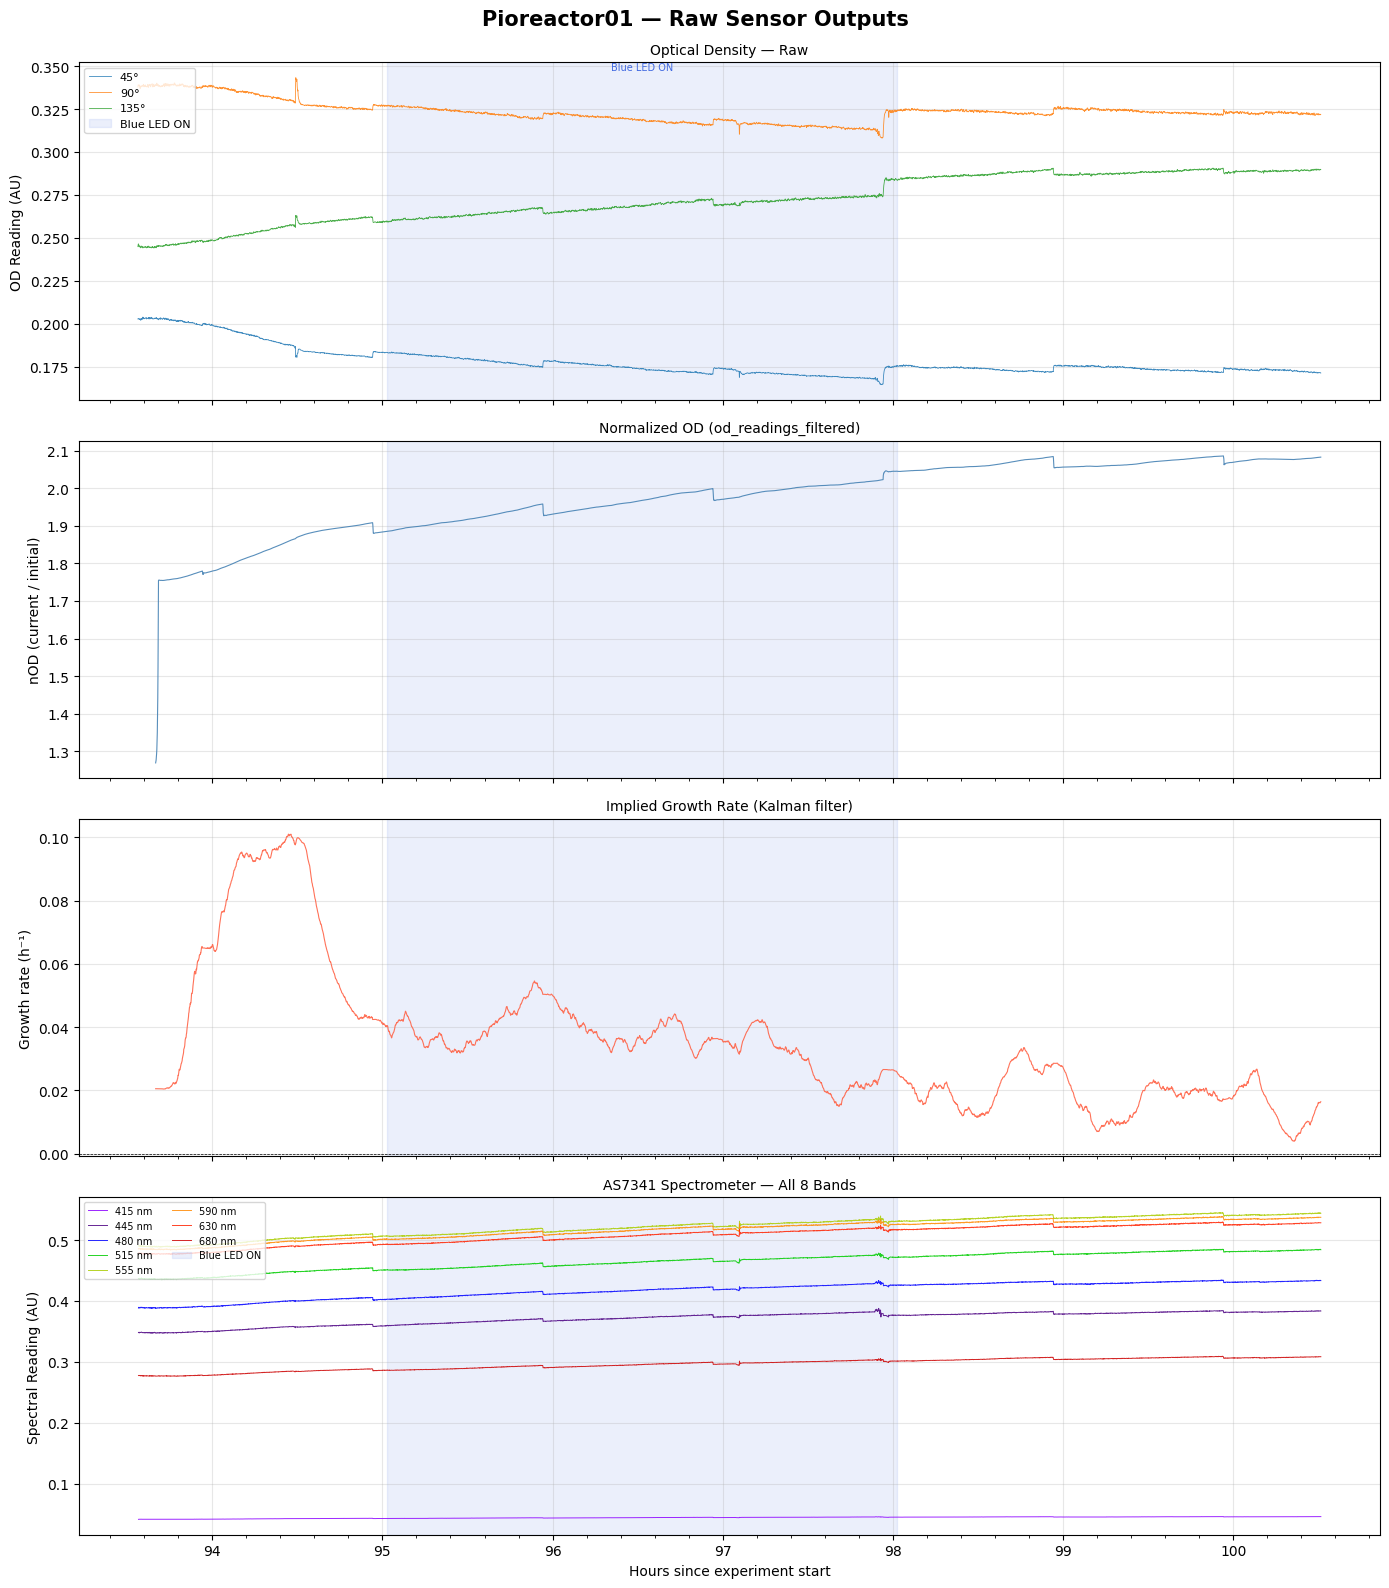

In [20]:
# plot_raw_sensors.py
# Plots all raw sensor outputs in 4 subplots:
#   1. OD readings (all angles)
#   2. Normalized OD (od_readings_filtered)
#   3. Implied growth rate
#   4. AS7341 spectrometer (all 8 bands)
#
# Usage: python plot_raw_sensors.py
# Update the FILE_* paths below to match your CSV locations.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── File paths ────────────────────────────────────────────────────────────────
FILE_OD         = "./data/02nd June (effect of blue LED)/od_readings-experiment_May-pioreactor01-20260602224829.csv"
FILE_NOD        = "./data/02nd June (effect of blue LED)/od_readings_filtered-experiment_May-pioreactor01-20260602224829.csv"
FILE_GR         = "./data/02nd June (effect of blue LED)/growth_rates-experiment_May-pioreactor01-20260602224829.csv"
FILE_SPEC       = "./data/02nd June (effect of blue LED)/as7341_spectrum_readings-experiment_May-pioreactor01-20260602224829.csv"
FILE_LED        = "./data/02nd June (effect of blue LED)/led_change_events-experiment_May-pioreactor01-20260602224829.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
od   = pd.read_csv(FILE_OD)
nod  = pd.read_csv(FILE_NOD)
gr   = pd.read_csv(FILE_GR)
spec = pd.read_csv(FILE_SPEC)
led  = pd.read_csv(FILE_LED)

# ── LED phase boundaries (channel C = blue LED) ───────────────────────────────
# Find ON and OFF events for channel C
led_C = led[led['channel'] == 'C'].sort_values('hours_since_experiment_created')
blue_on  = led_C[led_C['intensity'] > 0]['hours_since_experiment_created'].values
blue_off = led_C[led_C['intensity'] == 0]['hours_since_experiment_created'].values

def shade_blue_phases(ax):
    """Shade blue LED ON windows on a given axis."""
    for on, off in zip(blue_on, blue_off):
        ax.axvspan(on, off, color='royalblue', alpha=0.10, label='Blue LED ON')

# ── Spectrometer: pivot so each band is a column ──────────────────────────────
spec_pivot = spec.pivot_table(
    index='hours_since_experiment_created',
    columns='band',
    values='reading',
    aggfunc='mean'
).reset_index()

BAND_COLORS = {
    415: '#8B00FF',  # violet
    445: '#4B0082',  # indigo
    480: '#0000FF',  # blue
    515: '#00CC00',  # green
    555: '#AACC00',  # yellow-green
    590: '#FF8800',  # orange
    630: '#FF2200',  # red-orange
    680: '#CC0000',  # deep red
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 16), sharex=True)
fig.suptitle('Pioreactor01 — Raw Sensor Outputs', fontsize=15, fontweight='bold', y=0.99)

# ── Subplot 1: OD readings (all angles) ───────────────────────────────────────
ax1 = axes[0]
angle_styles = {45: ('tab:blue', '-'), 90: ('tab:orange', '-'), 135: ('tab:green', '-')}
for angle, (color, ls) in angle_styles.items():
    sub = od[od['angle'] == angle].sort_values('hours_since_experiment_created')
    ax1.plot(sub['hours_since_experiment_created'], sub['od_reading'],
             color=color, lw=0.6, linestyle=ls, label=f'{angle}°', alpha=0.85)
shade_blue_phases(ax1)
ax1.set_ylabel('OD Reading (AU)', fontsize=10)
ax1.set_title('Optical Density — Raw', fontsize=10)
ax1.legend(loc='upper left', fontsize=8)
ax1.grid(True, alpha=0.3)

# ── Subplot 2: Normalized OD ──────────────────────────────────────────────────
ax2 = axes[1]
nod_s = nod.sort_values('hours_since_experiment_created')
ax2.plot(nod_s['hours_since_experiment_created'], nod_s['normalized_od_reading'],
         color='steelblue', lw=0.8, alpha=0.9)
shade_blue_phases(ax2)
ax2.set_ylabel('nOD (current / initial)', fontsize=10)
ax2.set_title('Normalized OD (od_readings_filtered)', fontsize=10)
ax2.grid(True, alpha=0.3)

# ── Subplot 3: Implied growth rate ────────────────────────────────────────────
ax3 = axes[2]
gr_s = gr.sort_values('hours_since_experiment_created')
ax3.plot(gr_s['hours_since_experiment_created'], gr_s['rate'],
         color='tomato', lw=0.8, alpha=0.9)
shade_blue_phases(ax3)
ax3.set_ylabel('Growth rate (h⁻¹)', fontsize=10)
ax3.set_title('Implied Growth Rate (Kalman filter)', fontsize=10)
ax3.axhline(0, color='black', lw=0.5, linestyle='--')
ax3.grid(True, alpha=0.3)

# ── Subplot 4: AS7341 spectrometer ────────────────────────────────────────────
ax4 = axes[3]
for band in sorted(spec_pivot.columns[1:]):
    ax4.plot(spec_pivot['hours_since_experiment_created'], spec_pivot[band],
             color=BAND_COLORS.get(band, 'grey'), lw=0.7,
             label=f'{band} nm', alpha=0.85)
shade_blue_phases(ax4)
ax4.set_ylabel('Spectral Reading (AU)', fontsize=10)
ax4.set_title('AS7341 Spectrometer — All 8 Bands', fontsize=10)
ax4.set_xlabel('Hours since experiment start', fontsize=10)
ax4.legend(loc='upper left', fontsize=7, ncol=2)
ax4.grid(True, alpha=0.3)

# ── Shared x-axis formatting ──────────────────────────────────────────────────
for ax in axes:
    ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())

# Add blue LED annotation on top subplot
for on, off in zip(blue_on, blue_off):
    axes[0].annotate('Blue LED ON',
                     xy=((on + off) / 2, axes[0].get_ylim()[1]),
                     fontsize=7, color='royalblue', ha='center', va='top')

plt.tight_layout()
plt.show()


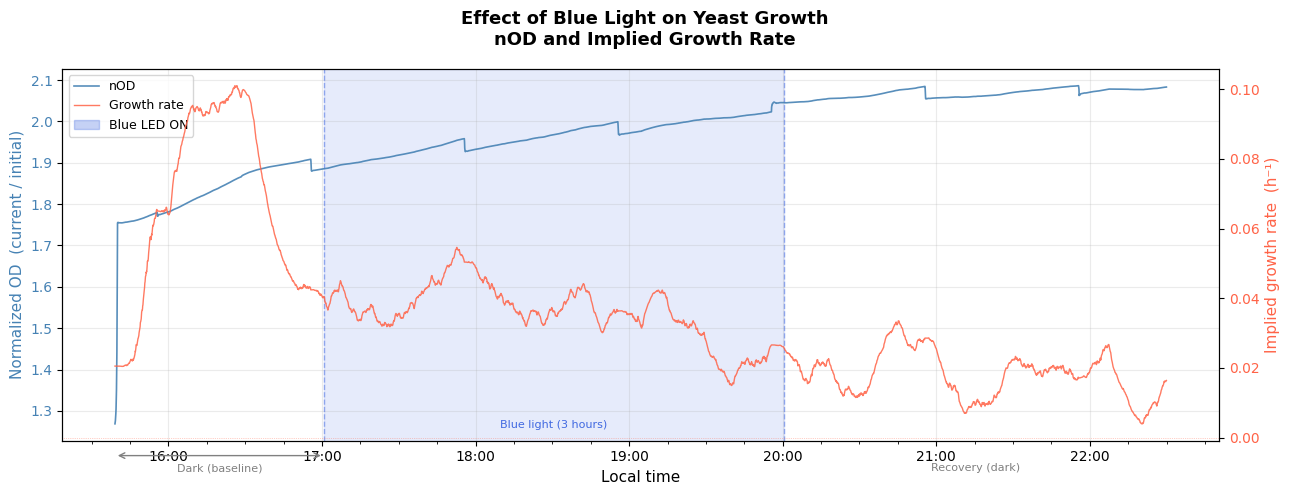

In [18]:
# plot_growth_nod.py
# Plots implied growth rate and normalized OD on a single figure
# with the blue LED phase shaded in blue.
#
# Usage: python plot_growth_nod.py
# Update the FILE_* paths below to match your CSV locations.

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as ticker

# ── File paths ────────────────────────────────────────────────────────────────
FILE_NOD = "./data/02nd June (effect of blue LED)/od_readings_filtered-experiment_May-pioreactor01-20260602224829.csv"
FILE_GR = "./data/02nd June (effect of blue LED)/growth_rates-experiment_May-pioreactor01-20260602224829.csv"
FILE_LED  = "./data/02nd June (effect of blue LED)/led_change_events-experiment_May-pioreactor01-20260602224829.csv"

# ── Load data ─────────────────────────────────────────────────────────────────
nod = pd.read_csv(FILE_NOD)
gr  = pd.read_csv(FILE_GR)
led = pd.read_csv(FILE_LED)

for df in [nod, gr, led]:
    df['timestamp_localtime'] = pd.to_datetime(df['timestamp_localtime'])

nod = nod.sort_values('timestamp_localtime')
gr = gr.sort_values('timestamp_localtime')
led = led.sort_values('timestamp_localtime')

# ── LED phase boundaries ──────────────────────────────────────────────────────
led_C    = led[led['channel'] == 'C'].sort_values('timestamp_localtime')
blue_on  = led_C[led_C['intensity'] > 0]['timestamp_localtime'].values
blue_off = led_C[led_C['intensity'] == 0]['timestamp_localtime'].values

# ── Figure: two y-axes sharing one x-axis ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(13, 5))
ax2 = ax1.twinx()

# ── Blue LED shading ──────────────────────────────────────────────────────────
for i, (on, off) in enumerate(zip(blue_on, blue_off)):
    label = 'Blue LED ON' if i == 0 else '_nolegend_'
    ax1.axvspan(on, off,
                color='royalblue', alpha=0.13, zorder=0, label=label)
    # Bracket lines at phase boundaries
    for t in [on, off]:
        ax1.axvline(t, color='royalblue', lw=1.0, linestyle='--', alpha=0.5)
    # Phase label at top
    mid = on + (off - on) / 2

# ── nOD (left axis) ───────────────────────────────────────────────────────────
l1, = ax1.plot(nod['timestamp_localtime'],
               nod['normalized_od_reading'],
               color='steelblue', lw=1.2, alpha=0.9, label='nOD', zorder=2)
ax1.set_ylabel('Normalized OD  (current / initial)', fontsize=11, color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xlabel('Local time', fontsize=11)

# ── Growth rate (right axis) ──────────────────────────────────────────────────
l2, = ax2.plot(gr['timestamp_localtime'],
               gr['rate'],
               color='tomato', lw=1.0, alpha=0.85, label='Growth rate', zorder=2)
ax2.set_ylabel('Implied growth rate  (h⁻¹)', fontsize=11, color='tomato')
ax2.tick_params(axis='y', labelcolor='tomato')
ax2.axhline(0, color='tomato', lw=0.5, linestyle=':', alpha=0.6)

# ── Phase annotations on x-axis ───────────────────────────────────────────────
x_min = pd.to_datetime(min(nod['timestamp_localtime'].min(),
                           gr['timestamp_localtime'].min()))
x_max = pd.to_datetime(max(nod['timestamp_localtime'].max(),
                           gr['timestamp_localtime'].max()))

if len(blue_on) > 0:
    # Dark before
    ax1.annotate('', xy=(blue_on[0], -0.04), xytext=(x_min, -0.04),
                 xycoords=('data', 'axes fraction'),
                 textcoords=('data', 'axes fraction'),
                 arrowprops=dict(arrowstyle='<->', color='grey', lw=1))
    dark_mid = x_min + (blue_on[0] - x_min) / 2
    ax1.text(dark_mid, -0.06, 'Dark (baseline)',
             ha='center', va='top', fontsize=8, color='grey',
             transform=ax1.get_xaxis_transform())
    # Blue phase
    blue_mid = blue_on[0] + (blue_off[0] - blue_on[0]) / 2
    ax1.text(blue_mid, 0.03, 'Blue light (3 hours)',
             ha='center', va='bottom', fontsize=8, color='royalblue',
             transform=ax1.get_xaxis_transform())
    # Recovery
    recovery_mid = blue_off[0] + (x_max - blue_off[0]) / 2
    ax1.text(recovery_mid, -0.06, 'Recovery (dark)',
             ha='center', va='top', fontsize=8, color='grey',
             transform=ax1.get_xaxis_transform())

# ── Legend, grid, title ───────────────────────────────────────────────────────
lines = [l1, l2]
labels = [l.get_label() for l in lines]
# Add blue LED patch to legend
from matplotlib.patches import Patch
blue_patch = Patch(color='royalblue', alpha=0.3, label='Blue LED ON')
ax1.legend(handles=[l1, l2, blue_patch], loc='upper left', fontsize=9)

ax1.grid(True, alpha=0.25, zorder=0)
ax1.xaxis.set_major_locator(mdates.AutoDateLocator())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax1.xaxis.set_minor_locator(ticker.AutoMinorLocator())

fig.suptitle('Effect of Blue Light on Yeast Growth\n'
             'nOD and Implied Growth Rate', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()


### Experiment: Red & Blue light phases run